# Capítulo 3: IA para la Detección de Amenazas

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

La detección de amenazas es una de las aplicaciones más efectivas de la IA en seguridad. Los modelos de IA pueden analizar tráfico de red, comportamiento de usuarios y registros de sistema para identificar **patrones anómalos** que indiquen una posible brecha de seguridad.

### Contenido del capítulo
| Sección | Técnica | Tipo |
|---|---|---|
| 3.2 | Carga y preprocesamiento de tráfico de red | Preparación |
| 3.3 | Isolation Forest | ML clásico (no supervisado) |
| 3.4 | Autoencoder | Deep Learning (no supervisado) |

---
## Sección 0: Generación de datos sintéticos

El dataset simula capturas de tráfico de red con las columnas requeridas por el capítulo:
`bytes_sent`, `bytes_recv`, `duration`, `protocol`, `src_port`, `dst_port`.

- **Tráfico normal** (~95 %): patrones coherentes de una red corporativa típica.
- **Tráfico anómalo** (~5 %): exfiltración masiva, puertos inusuales, duraciones extremas.

El archivo se guarda en `../data/network_traffic.csv` para ser reutilizado en capítulos posteriores.

In [55]:
import numpy as np
import pandas as pd
from pathlib import Path

RNG = np.random.default_rng(seed=42)
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

N_NORMAL   = 4750
N_ANOMALY  = 250   # ~5 % de contaminación

PUERTOS_COMUNES = [80, 443, 22, 21, 25, 53, 3306, 8080, 8443, 3389]
PROTOCOLOS      = ["TCP", "UDP", "ICMP"]

# --- Tráfico normal ---
normal = pd.DataFrame({
    "bytes_sent"  : RNG.normal(50_000,  15_000, N_NORMAL).clip(100),
    "bytes_recv"  : RNG.normal(120_000, 40_000, N_NORMAL).clip(100),
    "duration"    : RNG.normal(30, 12, N_NORMAL).clip(0.1, 300),
    "protocol"    : RNG.choice(PROTOCOLOS, N_NORMAL, p=[0.7, 0.25, 0.05]),
    "src_port"    : RNG.integers(1024, 65535, N_NORMAL),
    "dst_port"    : RNG.choice(PUERTOS_COMUNES, N_NORMAL),
    "label"       : 0,   # 0 = normal  (solo referencia, NO se usa en entrenamiento)
})

# --- Tráfico anómalo ---
# Tipo A: exfiltración masiva de datos
tipo_a = int(N_ANOMALY * 0.5)
# Tipo B: escaneo de puertos (muchos paquetes pequeños, puertos inusuales)
tipo_b = int(N_ANOMALY * 0.3)
# Tipo C: conexiones de muy larga duración (C2 / backdoor)
tipo_c = N_ANOMALY - tipo_a - tipo_b

anomaly_a = pd.DataFrame({
    "bytes_sent"  : RNG.normal(5_000_000, 1_000_000, tipo_a).clip(1_000_000),
    "bytes_recv"  : RNG.normal(10_000,    5_000,     tipo_a).clip(100),
    "duration"    : RNG.normal(5, 2, tipo_a).clip(0.1, 20),
    "protocol"    : RNG.choice(PROTOCOLOS, tipo_a),
    "src_port"    : RNG.integers(1024, 65535, tipo_a),
    "dst_port"    : RNG.integers(1024, 65535, tipo_a),  # puertos aleatorios
    "label"       : 1,
})

anomaly_b = pd.DataFrame({
    "bytes_sent"  : RNG.normal(64, 10, tipo_b).clip(20, 200),
    "bytes_recv"  : RNG.normal(64, 10, tipo_b).clip(20, 200),
    "duration"    : RNG.normal(0.05, 0.02, tipo_b).clip(0.01, 0.5),
    "protocol"    : ["TCP"] * tipo_b,
    "src_port"    : RNG.integers(1024, 65535, tipo_b),
    "dst_port"    : RNG.integers(1, 1024, tipo_b),      # puertos privilegiados
    "label"       : 1,
})

anomaly_c = pd.DataFrame({
    "bytes_sent"  : RNG.normal(1_000, 500, tipo_c).clip(100),
    "bytes_recv"  : RNG.normal(1_000, 500, tipo_c).clip(100),
    "duration"    : RNG.normal(7200, 1800, tipo_c).clip(3600, 86400),  # horas
    "protocol"    : ["TCP"] * tipo_c,
    "src_port"    : RNG.integers(1024, 65535, tipo_c),
    "dst_port"    : RNG.choice([4444, 1337, 31337, 9001, 6667], tipo_c),  # C2 típicos
    "label"       : 1,
})

df = pd.concat([normal, anomaly_a, anomaly_b, anomaly_c], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # mezclar filas

ruta = DATA_DIR / "network_traffic.csv"
df.to_csv(ruta, index=False)

print(f"Dataset guardado en: {ruta}")
print(f"Total de registros : {len(df):,}")
print(f"  Normal           : {(df.label == 0).sum():,} ({(df.label==0).mean()*100:.1f}%)")
print(f"  Anómalo          : {(df.label == 1).sum():,} ({(df.label==1).mean()*100:.1f}%)")
print(f"\nColumnas: {list(df.columns)}")

Dataset guardado en: ..\data\network_traffic.csv
Total de registros : 5,000
  Normal           : 4,750 (95.0%)
  Anómalo          : 250 (5.0%)

Columnas: ['bytes_sent', 'bytes_recv', 'duration', 'protocol', 'src_port', 'dst_port', 'label']


---
## 3.2. Recolección y preprocesamiento de datos

### 3.2.1. Carga de datos de tráfico de red

In [56]:
DATA_DIR = Path("../data")

data = pd.read_csv(DATA_DIR / "network_traffic.csv")

print("=== Información del dataset ===")
print(data.info())
print("\n=== Primeras filas ===")
print(data.head())
print("\n=== Estadísticas descriptivas ===")
print(data.describe())
print("\n=== Valores nulos por columna ===")
print(data.isnull().sum())

=== Información del dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bytes_sent  5000 non-null   float64
 1   bytes_recv  5000 non-null   float64
 2   duration    5000 non-null   float64
 3   protocol    5000 non-null   str    
 4   src_port    5000 non-null   int64  
 5   dst_port    5000 non-null   int64  
 6   label       5000 non-null   int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 273.6 KB
None

=== Primeras filas ===
     bytes_sent     bytes_recv   duration protocol  src_port  dst_port  label
0  40630.948877  148733.918453  22.414616      TCP      6010        25      0
1  51240.773028  187867.669489  38.767879      TCP     21259        80      0
2  37597.863419   83555.898197  24.177736      TCP     59996      3389      0
3  72080.218497  104910.573036  18.903189      TCP     42116      3306      0
4  35360.617758  142801.3

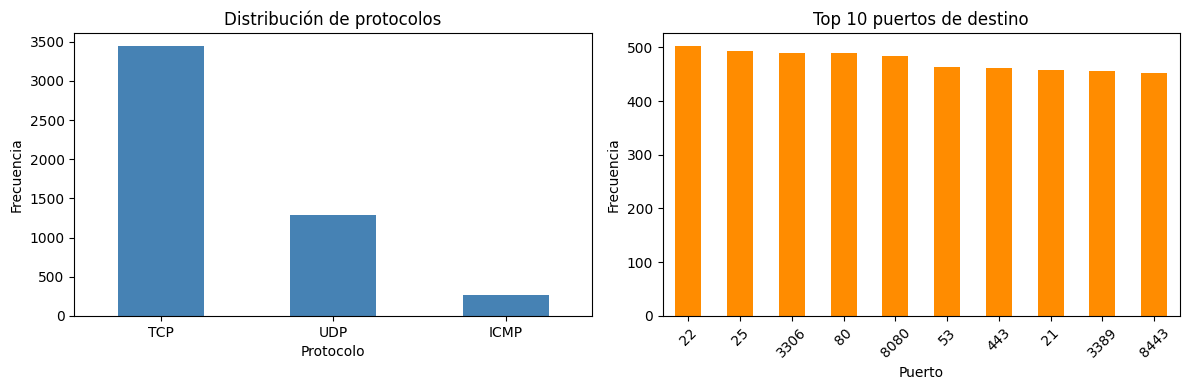

In [57]:
# Distribución de protocolos y puertos destino más frecuentes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["protocol"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de protocolos")
axes[0].set_xlabel("Protocolo")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis="x", rotation=0)

data["dst_port"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 puertos de destino")
axes[1].set_xlabel("Puerto")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(DATA_DIR / "eda_protocolos_puertos.png", dpi=150)
plt.show()

### 3.2.2. Preprocesamiento y normalización

In [58]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Eliminar filas con valores nulos
data = data.dropna()

# 2. Codificar la variable categórica 'protocol'
le = LabelEncoder()
data["protocol"] = le.fit_transform(data["protocol"])
print("Clases del LabelEncoder:", dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Seleccionar características numéricas
FEATURE_COLS = ["bytes_sent", "bytes_recv", "duration", "src_port", "dst_port", "protocol"]
features = data[FEATURE_COLS].copy()

# 4. Normalizar entre 0 y 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)
scaled_df   = pd.DataFrame(scaled_data, columns=FEATURE_COLS)

print("\nDatos escalados (primeras 5 filas):")
print(scaled_df.head())

Clases del LabelEncoder: {'ICMP': np.int64(0), 'TCP': np.int64(1), 'UDP': np.int64(2)}

Datos escalados (primeras 5 filas):
   bytes_sent  bytes_recv  duration  src_port  dst_port  protocol
0    0.005286    0.529179  0.001933  0.076977  0.000307       0.5
1    0.006668    0.668447  0.003345  0.313443  0.001151       0.5
2    0.004891    0.297225  0.002086  0.914138  0.051945       0.5
3    0.009382    0.373222  0.001630  0.636873  0.050671       0.5
4    0.004600    0.508066  0.001757  0.636640  0.050671       0.5


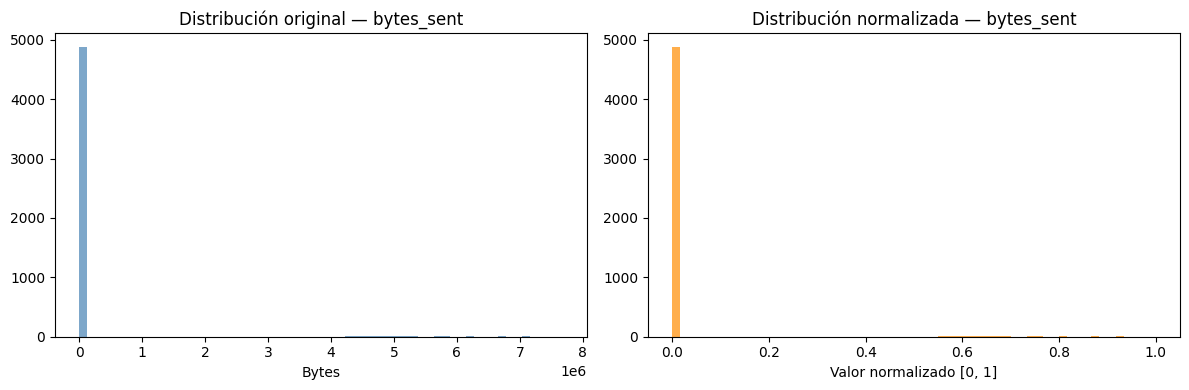

In [59]:
# Visualizar distribución original vs normalizada para bytes_sent
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(features["bytes_sent"], bins=60, color="steelblue", alpha=0.7)
axes[0].set_title("Distribución original — bytes_sent")
axes[0].set_xlabel("Bytes")

axes[1].hist(scaled_df["bytes_sent"], bins=60, color="darkorange", alpha=0.7)
axes[1].set_title("Distribución normalizada — bytes_sent")
axes[1].set_xlabel("Valor normalizado [0, 1]")

plt.tight_layout()
plt.savefig(DATA_DIR / "network_distribution.png", dpi=150)
plt.show()

---
## 3.3. Detección de anomalías con Isolation Forest

El algoritmo **Isolation Forest** aísla anomalías particionando el espacio de características de manera recursiva. Las anomalías son puntos que se aíslan con **pocas particiones**, lo que los hace fáciles de separar del resto.

- `1`  → muestra **normal**  
- `-1` → **anomalía** detectada

In [60]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Cargar y escalar (reutilizamos scaled_data del paso anterior)

# 2. Entrenar Isolation Forest
#    contamination: fracción esperada de anomalías (5 %)
model_if = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
model_if.fit(scaled_data)

# 3. Predicción
predictions = model_if.predict(scaled_data)       # 1 = normal | -1 = anomalía
scores      = model_if.decision_function(scaled_data)  # puntuación de anomalía

data = data.copy()
data["anomaly"]       = predictions
data["anomaly_score"] = scores

# 4. Resultados
anomalous = data[data["anomaly"] == -1]
normal    = data[data["anomaly"] ==  1]

print(f"Total de muestras    : {len(data):,}")
print(f"Muestras normales    : {len(normal):,}")
print(f"Anomalías detectadas : {len(anomalous):,}")
print("\nTop 10 anomalías (menor puntuación = más anómalo):")
print(anomalous.sort_values("anomaly_score")[["bytes_sent", "bytes_recv", "duration", "dst_port", "anomaly_score"]].head(10))

Total de muestras    : 5,000
Muestras normales    : 4,750
Anomalías detectadas : 250

Top 10 anomalías (menor puntuación = más anómalo):
        bytes_sent    bytes_recv  duration  dst_port  anomaly_score
735   6.166072e+06   4526.910166  8.739777     64161      -0.205625
2150  5.873857e+06  14574.311773  3.885052     48921      -0.198479
2229  5.987518e+06   9797.143933  5.302255     59667      -0.195071
2013  5.880647e+06   5375.727805  7.262802     50554      -0.194908
3615  5.722970e+06  16658.825852  3.855093     56149      -0.194720
3370  5.321814e+06  12898.995882  7.764726     56860      -0.194543
4060  7.145418e+06  12288.519790  3.606377     52591      -0.192452
1508  6.150296e+06  11136.379082  7.568541     57727      -0.192203
2979  4.635510e+06   7276.467886  6.125141     58310      -0.191673
2831  6.497956e+06   9906.809332  0.100000     60460      -0.191386


=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      4750
    Anomalía       0.70      0.70      0.70       250

    accuracy                           0.97      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.97      0.97      0.97      5000



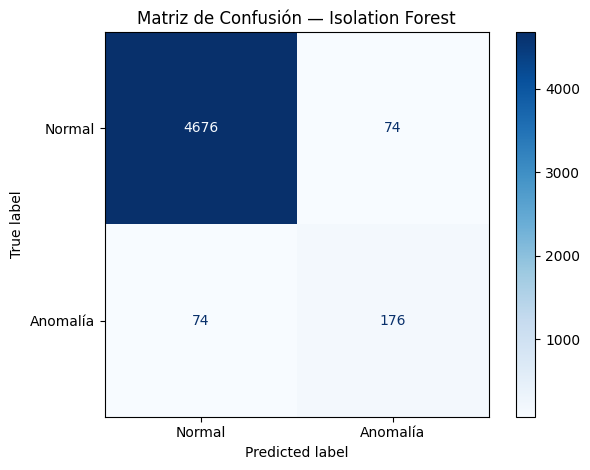

In [61]:
# Evaluación contra la etiqueta real (label: 0=normal, 1=anómalo)
# Convertimos: IF usa -1 para anomalía; la etiqueta usa 1
y_true = data["label"].values
y_pred = (data["anomaly"] == -1).astype(int).values

print("=== Reporte de clasificación ===")
print(classification_report(y_true, y_pred, target_names=["Normal", "Anomalía"]))

# cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomalía"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión — Isolation Forest")
plt.tight_layout()
plt.savefig(DATA_DIR / "if_confusion_matrix.png", dpi=150)
plt.show()

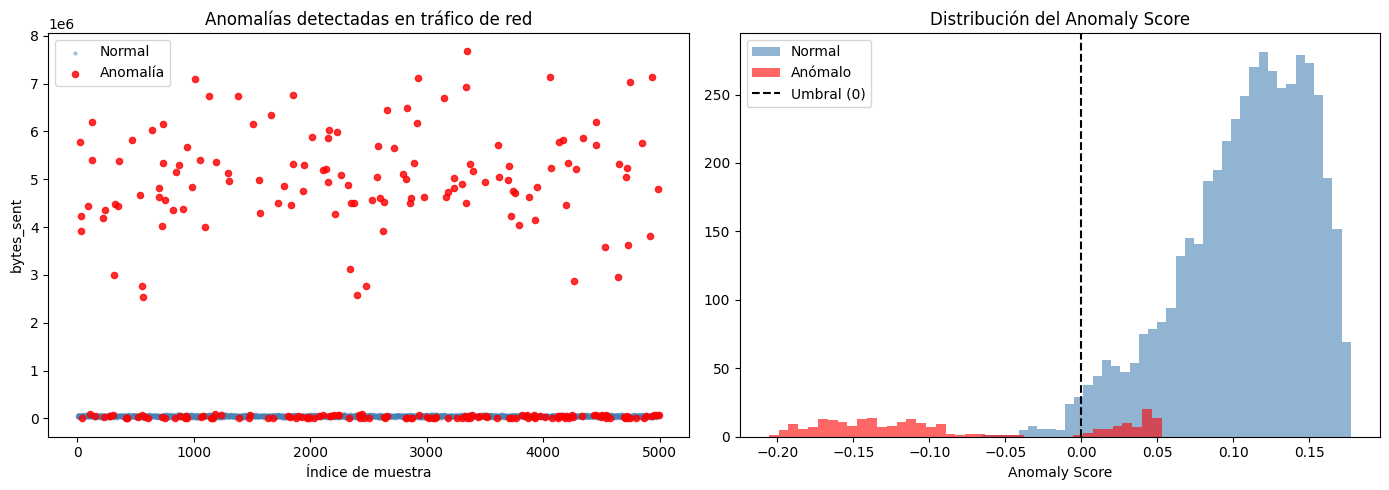

In [62]:
# Visualización: normal vs anomalía en bytes_sent
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: índice vs bytes_sent
axes[0].scatter(normal.index,    normal["bytes_sent"],    s=4,  c="steelblue",  alpha=0.4, label="Normal")
axes[0].scatter(anomalous.index, anomalous["bytes_sent"], s=20, c="red",        alpha=0.8, label="Anomalía")
axes[0].set_xlabel("Índice de muestra")
axes[0].set_ylabel("bytes_sent")
axes[0].set_title("Anomalías detectadas en tráfico de red")
axes[0].legend()

# Histograma de anomaly_score
axes[1].hist(data[data["label"]==0]["anomaly_score"], bins=40, alpha=0.6, color="steelblue", label="Normal")
axes[1].hist(data[data["label"]==1]["anomaly_score"], bins=40, alpha=0.6, color="red",       label="Anómalo")
axes[1].axvline(0, color="black", linestyle="--", label="Umbral (0)")
axes[1].set_xlabel("Anomaly Score")
axes[1].set_title("Distribución del Anomaly Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "anomaly_detection.png", dpi=150)
plt.show()

---
## 3.4. Detección de intrusiones con Autoencoder (Deep Learning)

Un **autoencoder** aprende a reconstruir entradas normales. Cuando procesa datos anómalos, el **error de reconstrucción (MSE) es alto**, permitiendo detectar intrusiones no vistas durante el entrenamiento.

Arquitectura:
```
Entrada (6) → Dense(16) → Dense(8)  ← Codificador
             → Dense(16) → Salida(6) ← Decodificador
```

In [63]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

# 1. Preparar datos — entrenar SOLO con tráfico normal
X_all    = scaled_data
y_all    = data["label"].values

X_normal = X_all[y_all == 0]   # solo muestras normales para entrenar
X_train, X_val = train_test_split(X_normal, test_size=0.15, random_state=42)

# Test: mezcla de normales y anómalos
X_test   = X_all
y_test   = y_all

print(f"Entrenamiento : {X_train.shape[0]:,} muestras normales")
print(f"Validación    : {X_val.shape[0]:,}  muestras normales")
print(f"Test          : {X_test.shape[0]:,} muestras (normal + anómalo)")

Entrenamiento : 4,037 muestras normales
Validación    : 713  muestras normales
Test          : 5,000 muestras (normal + anómalo)


In [64]:
# 2. Definir arquitectura del Autoencoder
input_dim    = X_train.shape[1]
encoding_dim = 8

def build_autoencoder(input_dim, encoding_dim=8):
    inp     = keras.Input(shape=(input_dim,))
    # Codificador
    encoded = layers.Dense(16, activation="relu")(inp)
    encoded = layers.Dense(encoding_dim, activation="relu")(encoded)
    # Decodificador
    decoded = layers.Dense(16, activation="relu")(encoded)
    decoded = layers.Dense(input_dim, activation="sigmoid")(decoded)

    autoencoder = keras.Model(inp, decoded, name="autoencoder")
    encoder     = keras.Model(inp, encoded, name="encoder")
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(input_dim, encoding_dim)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 494 (1.93 KB)

 Trainable params: 494 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# 3. Entrenar
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    verbose=1
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1194 - val_loss: 0.0909
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0628 - val_loss: 0.0400
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0307 - val_loss: 0.0252
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 - val_loss: 0.0190
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 - val_loss: 0.0147
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0137 - val_loss: 0.0131
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0122 - val_loss: 0.0116
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0106 - val_loss: 0.0097
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - val_loss: 0.0080
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073 - val_loss: 0.0064
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 - val_loss: 0.0055
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054 - val_lo

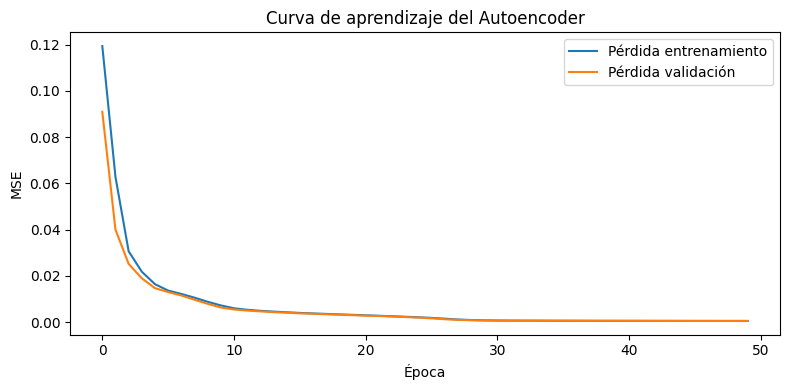

In [66]:
# 4. Curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Pérdida entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida validación")
plt.title("Curva de aprendizaje del Autoencoder")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "autoencoder_loss.png", dpi=150)
plt.show()

In [67]:
# 5. Calcular error de reconstrucción sobre el conjunto de test
X_pred  = autoencoder.predict(X_test)
mse_err = np.mean(np.power(X_test - X_pred, 2), axis=1)

# Umbral: percentil 95 del error en datos de entrenamiento
X_train_pred = autoencoder.predict(X_train)
train_mse    = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
threshold    = np.percentile(train_mse, 95)

print(f"Umbral de detección (percentil 95): {threshold:.6f}")

# Clasificar anomalías
y_pred_ae = (mse_err > threshold).astype(int)

print(f"\nAnomálías detectadas por Autoencoder : {y_pred_ae.sum():,}")
print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred_ae, target_names=["Normal", "Anomalía"]))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step
Umbral de detección (percentil 95): 0.001601

Anomálías detectadas por Autoencoder : 493

=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      4750
    Anomalía       0.51      1.00      0.67       250

    accuracy                           0.95      5000
   macro avg       0.75      0.97      0.82      5000
weighted avg       0.98      0.95      0.96      5000



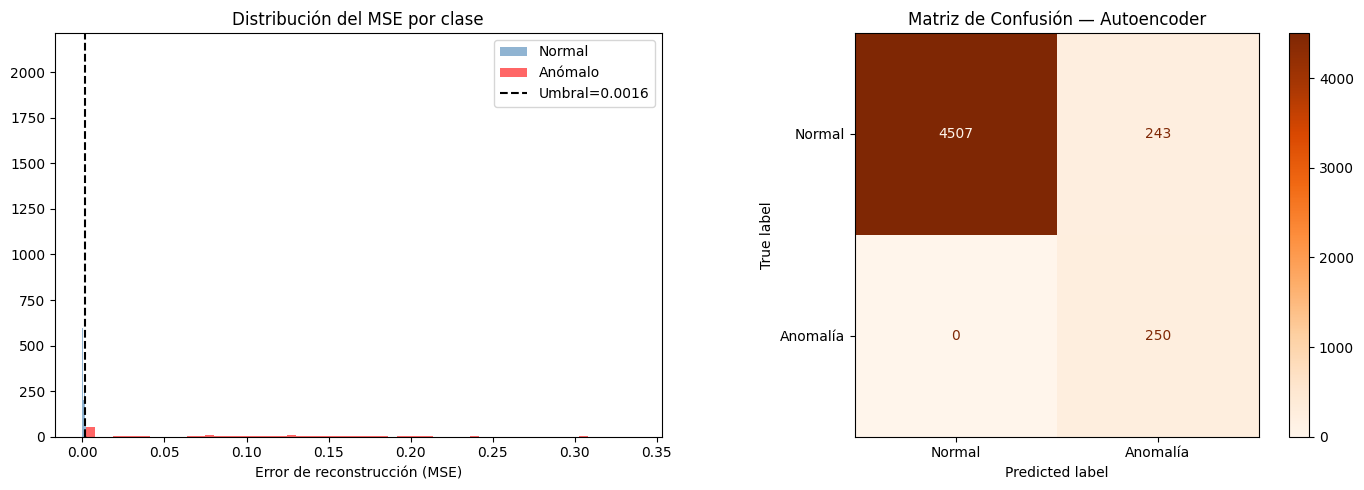

In [68]:
# 6. Visualización del error de reconstrucción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del MSE por clase
axes[0].hist(mse_err[y_test == 0], bins=60, alpha=0.6, color="steelblue", label="Normal",  density=True)
axes[0].hist(mse_err[y_test == 1], bins=60, alpha=0.6, color="red",       label="Anómalo", density=True)
axes[0].axvline(threshold, color="black", linestyle="--", label=f"Umbral={threshold:.4f}")
axes[0].set_xlabel("Error de reconstrucción (MSE)")
axes[0].set_title("Distribución del MSE por clase")
axes[0].legend()

# Matriz de confusión
cm_ae   = confusion_matrix(y_test, y_pred_ae)
disp_ae = ConfusionMatrixDisplay(cm_ae, display_labels=["Normal", "Anomalía"])
disp_ae.plot(ax=axes[1], cmap="Oranges")
axes[1].set_title("Matriz de Confusión — Autoencoder")

plt.tight_layout()
plt.savefig(DATA_DIR / "autoencoder_detection.png", dpi=150)
plt.show()

---
## Comparación de modelos

| Modelo | Ventaja | Desventaja |
|---|---|---|
| **Isolation Forest** | Rápido, sin necesidad de GPU | Menos preciso en anomalías complejas |
| **Autoencoder** | Captura patrones no lineales | Requiere más datos y tiempo de entrenamiento |

---
**Siguiente:** Capítulo 4 → IA para la Detección de Malware